### Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Install Java

In [2]:
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless -qq
!java -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


### Install PySpark

In [3]:
!pip install pyspark --quiet

### Configure Java Home

In [4]:
import os
import subprocess
import pyspark

result = subprocess.run(
    "java -XshowSettings:property -version 2>&1 | grep 'java.home'",
    shell=True, capture_output=True, text=True
)
java_home_path = result.stdout.strip().split("=")[-1].strip()
os.environ["JAVA_HOME"] = java_home_path
print(f"JAVA_HOME set to : {java_home_path}")
print(f"PySpark version  : {pyspark.__version__}")

JAVA_HOME set to : /usr/lib/jvm/java-17-openjdk-amd64
PySpark version  : 4.0.2


### Start Spark Session

In [5]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("RandomForestModeling")
    .master("local[*]")
    .config("spark.driver.memory", "35g")
    .config("spark.sql.shuffle.partitions", "200")
    .getOrCreate()
)

spark.conf.set("spark.sql.parquet.int96RebaseModeInRead", "CORRECTED")
spark.conf.set("spark.sql.legacy.parquet.nanosAsLong", "true")
spark.sparkContext.setLogLevel("WARN")
spark

### Load Train and Validation Data

In [6]:
BASE_PATH = "/content/drive/MyDrive/OMDS Capstone/Data/flights_all_features_encoded"

TRAIN_PATH    = f"{BASE_PATH}/train.parquet"
VALIDATE_PATH = f"{BASE_PATH}/val.parquet"
TEST_PATH     = f"{BASE_PATH}/test.parquet"

train_df    = spark.read.parquet(TRAIN_PATH)
validate_df = spark.read.parquet(VALIDATE_PATH)

print("Data loaded.")

Data loaded.


### Inspect Columns

In [7]:
print(train_df.columns)

['Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'FlightDate', 'Reporting_Airline', 'Flight_Number_Reporting_Airline', 'Origin', 'Dest', 'CRSDepTime', 'DepTimeBlk', 'CRSArrTime', 'ArrDel15', 'CRSElapsedTime', 'Distance', 'DistanceGroup', 'date', 'dep_hour', 'arr_hour', 'dep_hour_minus2', 'arr_hour_minus2', 'origin_temp_f', 'origin_dewpoint_f', 'origin_humidity', 'origin_feels_like_f', 'origin_wind_kts', 'origin_gust_kts', 'origin_visibility', 'origin_precip_in', 'origin_wx_codes', 'origin_is_rain', 'origin_is_snow', 'origin_is_fog', 'origin_low_visibility', 'origin_high_wind', 'origin_severe_weather', 'dest_temp_f', 'dest_dewpoint_f', 'dest_humidity', 'dest_feels_like_f', 'dest_wind_kts', 'dest_gust_kts', 'dest_visibility', 'dest_precip_in', 'dest_wx_codes', 'dest_is_rain', 'dest_is_snow', 'dest_is_fog', 'dest_low_visibility', 'dest_high_wind', 'dest_severe_weather', 'is_weekend', 'is_holiday', 'origin_weather_missing', 'dest_weather_missing', 'carrier_delay_rate_30d', 'carrier_

### Cast Label Column to Double

In [8]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

# Cast ArrDel15 to Double — Spark ML requires numeric label column
train_df    = train_df.withColumn("ArrDel15", F.col("ArrDel15").cast(DoubleType()))
validate_df = validate_df.withColumn("ArrDel15", F.col("ArrDel15").cast(DoubleType()))

print("ArrDel15 dtype:", dict(train_df.dtypes)["ArrDel15"])

ArrDel15 dtype: double


### Define Feature Columns

In [9]:
feature_cols = [
    "Month", "DayofMonth", "DayOfWeek", "dep_hour", "arr_hour",
    "CRSElapsedTime", "Distance", "DistanceGroup",
    "is_weekend", "is_holiday",
    "origin_delay_rate", "dest_delay_rate",
    "carrier_delay_rate_30d", "carrier_delay_rate_90d",
    "origin_delay_rate_30d", "origin_delay_rate_90d",
    "dest_delay_rate_30d", "dest_delay_rate_90d",
    "origin_departures_3h",
    "origin_temp_f", "origin_dewpoint_f", "origin_humidity",
    "origin_feels_like_f", "origin_wind_kts", "origin_gust_kts",
    "origin_visibility", "origin_precip_in",
    "origin_is_rain", "origin_is_snow", "origin_is_fog",
    "origin_low_visibility", "origin_high_wind", "origin_severe_weather",
    "dest_temp_f", "dest_dewpoint_f", "dest_humidity",
    "dest_feels_like_f", "dest_wind_kts", "dest_gust_kts",
    "dest_visibility", "dest_precip_in",
    "dest_is_rain", "dest_is_snow", "dest_is_fog",
    "dest_low_visibility", "dest_high_wind", "dest_severe_weather",
]

print(f"Total features: {len(feature_cols)}")

Total features: 47


### Stratified Sampling and Feature Assembly

In [10]:
from pyspark.ml.feature import VectorAssembler

SAMPLE_FRACTION = 0.20

# Stratified sample by Year x Month x Class — preserves temporal and class distribution
df_train_keyed = train_df.withColumn(
    'strat_key',
    F.concat_ws('_',
        F.col('Year').cast('string'),
        F.col('Month').cast('string'),
        F.col('ArrDel15').cast('string')
    )
)

strata = [row['strat_key'] for row in
          df_train_keyed.select('strat_key').distinct().collect()]
fractions = {s: SAMPLE_FRACTION for s in strata}

train_sample = (
    df_train_keyed
    .sampleBy('strat_key', fractions=fractions, seed=42)
    .drop('strat_key')
)

train_n = train_sample.count()
print(f"Stratified sample : {train_n:,} rows ({100*SAMPLE_FRACTION:.0f}% of train)")

# Verify class balance preserved
counts = train_sample.groupBy('ArrDel15').count().collect()
counts_dict = {row['ArrDel15']: row['count'] for row in counts}
sample_rate = counts_dict[1] / (counts_dict[0] + counts_dict[1])
actual_ratio = counts_dict[0] / counts_dict[1]
print(f"Sample delay rate : {sample_rate:.4f}  (original: 0.1785)")
print(f"Actual class ratio: {actual_ratio:.2f}  (using scale_pos_weight: 3.5)")

# Year distribution check
print("\nSampled train by year:")
train_sample.groupBy('Year').count().orderBy('Year').show()

# Weight column — using 3.5 instead of full ratio (4.59) to balance precision/recall
scale_pos_weight = 3.5
train_sample = train_sample.withColumn(
    'weight',
    F.when(F.col('ArrDel15') == 1, scale_pos_weight).otherwise(1.0)
)

# Drop features column if already exists from a previous run
if 'features' in train_sample.columns:
    train_sample = train_sample.drop('features')
if 'features' in validate_df.columns:
    validate_df = validate_df.drop('features')

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

train_sample = assembler.transform(train_sample)
validate_df  = assembler.transform(validate_df)

print("Assembler applied.")

Stratified sample : 6,231,167 rows (20% of train)
Sample delay rate : 0.1788  (original: 0.1785)
Actual class ratio: 4.59  (using scale_pos_weight: 3.5)

Sampled train by year:
+----+-------+
|Year|  count|
+----+-------+
|2018|1413764|
|2019|1452111|
|2020| 880452|
|2021|1176594|
|2022|1308246|
+----+-------+

Assembler applied.


### Train Random Forest

In [11]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="ArrDel15",
    featuresCol="features",
    weightCol="weight",
    numTrees=100,
    maxDepth=12,
    maxBins=64,
    featureSubsetStrategy="onethird",
    minInstancesPerNode=5,
    seed=42
)

print("Training Random Forest...")
rf_model = rf.fit(train_sample)
print("Training complete.")

Training Random Forest...
Training complete.


### Validation Metrics

In [12]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

predictions = rf_model.transform(validate_df)

roc_auc = BinaryClassificationEvaluator(
    labelCol="ArrDel15", metricName="areaUnderROC"
).evaluate(predictions)

pr_auc = BinaryClassificationEvaluator(
    labelCol="ArrDel15", metricName="areaUnderPR"
).evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="ArrDel15", metricName="f1"
).evaluate(predictions)

print(f"Validation ROC-AUC : {roc_auc:.4f}")
print(f"Validation PR-AUC  : {pr_auc:.4f}")
print(f"Validation F1      : {f1:.4f}")

# Class-specific precision and recall from confusion matrix
cm_rows = predictions.groupBy('ArrDel15', 'prediction').count().collect()
cm = {(int(row['ArrDel15']), int(row['prediction'])): row['count'] for row in cm_rows}

tn = cm.get((0, 0), 0)
fp = cm.get((0, 1), 0)
fn = cm.get((1, 0), 0)
tp = cm.get((1, 1), 0)

delayed_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
delayed_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
ontime_precision  = tn / (tn + fn) if (tn + fn) > 0 else 0
ontime_recall     = tn / (tn + fp) if (tn + fp) > 0 else 0

print(f"\n{'Class':<12} {'Precision':>10} {'Recall':>10}")
print(f"{'-'*34}")
print(f"{'On-Time':<12} {ontime_precision:>10.4f} {ontime_recall:>10.4f}")
print(f"{'Delayed':<12} {delayed_precision:>10.4f} {delayed_recall:>10.4f}")

# Raw confusion matrix counts
print("\nConfusion matrix (counts):")
predictions.groupBy('ArrDel15', 'prediction').count().orderBy('ArrDel15', 'prediction').show()

Validation ROC-AUC : 0.6910
Validation PR-AUC  : 0.3805
Validation F1      : 0.7083

Class         Precision     Recall
----------------------------------
On-Time          0.8624     0.7166
Delayed          0.3377     0.5584

Confusion matrix (counts):
+--------+----------+-------+
|ArrDel15|prediction|  count|
+--------+----------+-------+
|     0.0|       0.0|3838411|
|     0.0|       1.0|1518293|
|     1.0|       0.0| 612426|
|     1.0|       1.0| 774273|
+--------+----------+-------+



### Train vs Validation Comparison

In [13]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

train_preds = rf_model.transform(train_sample)

train_roc = BinaryClassificationEvaluator(labelCol="ArrDel15", metricName="areaUnderROC").evaluate(train_preds)
train_pr  = BinaryClassificationEvaluator(labelCol="ArrDel15", metricName="areaUnderPR").evaluate(train_preds)
train_f1  = MulticlassClassificationEvaluator(labelCol="ArrDel15", metricName="f1").evaluate(train_preds)

cm_rows = train_preds.groupBy('ArrDel15', 'prediction').count().collect()
cm_t = {(int(row['ArrDel15']), int(row['prediction'])): row['count'] for row in cm_rows}
tn_t, fp_t, fn_t, tp_t = cm_t.get((0,0),0), cm_t.get((0,1),0), cm_t.get((1,0),0), cm_t.get((1,1),0)

train_delayed_precision = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
train_delayed_recall    = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0

print(f"{'Metric':<22} {'Train':>8}  {'Val':>8}  {'Gap':>8}")
print("-" * 52)
print(f"{'ROC-AUC':<22} {train_roc:>8.4f}  {roc_auc:>8.4f}  {train_roc - roc_auc:>8.4f}")
print(f"{'PR-AUC':<22} {train_pr:>8.4f}  {pr_auc:>8.4f}  {train_pr - pr_auc:>8.4f}")
print(f"{'F1':<22} {train_f1:>8.4f}  {f1:>8.4f}  {train_f1 - f1:>8.4f}")
print(f"{'Delayed Precision':<22} {train_delayed_precision:>8.4f}  {delayed_precision:>8.4f}  {train_delayed_precision - delayed_precision:>8.4f}")
print(f"{'Delayed Recall':<22} {train_delayed_recall:>8.4f}  {delayed_recall:>8.4f}  {train_delayed_recall - delayed_recall:>8.4f}")

Metric                    Train       Val       Gap
----------------------------------------------------
ROC-AUC                  0.7112    0.6910    0.0202
PR-AUC                   0.3798    0.3805   -0.0007
F1                       0.7617    0.7083    0.0533
Delayed Precision        0.3498    0.3377    0.0121
Delayed Recall           0.4856    0.5584   -0.0728


### Confusion Matrix Plot

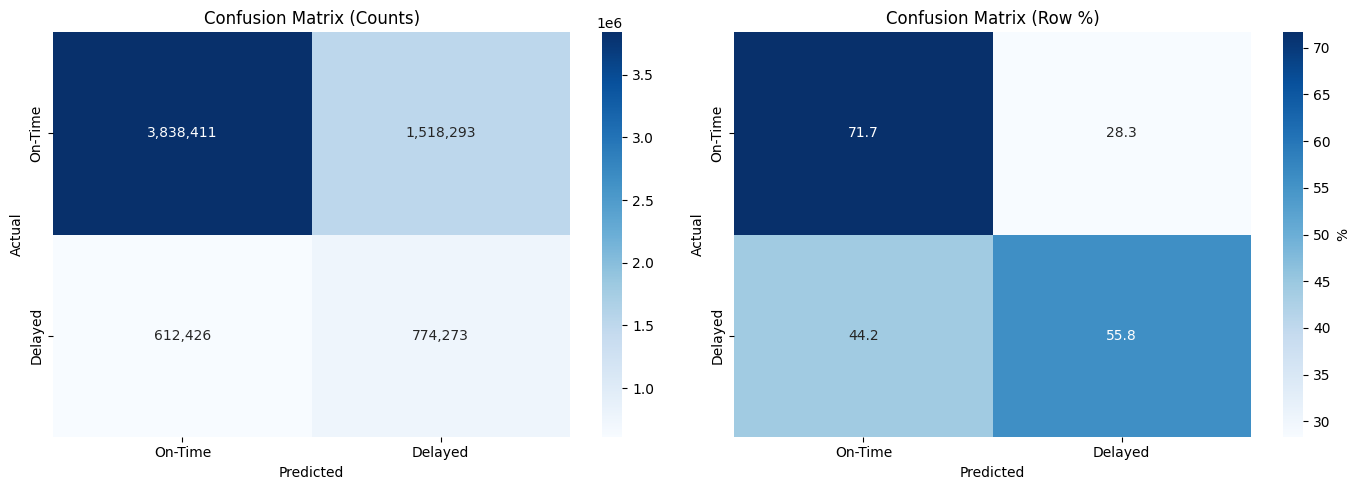

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cm_pd = (
    predictions.groupBy('ArrDel15', 'prediction').count()
    .toPandas()
    .pivot(index='ArrDel15', columns='prediction', values='count')
    .fillna(0).astype(int)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm_pd, annot=True, fmt=',d', cmap='Blues', ax=axes[0],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Row-normalized (recall view)
cm_pct = cm_pd.div(cm_pd.sum(axis=1), axis=0) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'],
            cbar_kws={'label': '%'})
axes[1].set_title('Confusion Matrix (Row %)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Feature Importances

In [15]:
# Feature importances — top 20
import pandas as pd

importances = rf_model.featureImportances
feat_imp_df = pd.DataFrame({
    "feature":    feature_cols,
    "importance": importances.toArray()
}).sort_values("importance", ascending=False)

print(feat_imp_df.head(20).to_string(index=False))

               feature  importance
              dep_hour    0.162339
carrier_delay_rate_30d    0.155393
              arr_hour    0.089872
 origin_delay_rate_30d    0.083741
   dest_delay_rate_30d    0.064580
 origin_severe_weather    0.062784
   dest_severe_weather    0.042669
carrier_delay_rate_90d    0.038397
      origin_precip_in    0.037949
        dest_precip_in    0.025273
        origin_is_snow    0.024029
 origin_delay_rate_90d    0.017036
         origin_temp_f    0.016892
                 Month    0.014924
   dest_delay_rate_90d    0.013493
   origin_feels_like_f    0.013245
     origin_dewpoint_f    0.012904
       dest_delay_rate    0.010770
  origin_departures_3h    0.010512
          dest_is_rain    0.009659


### Threshold Tuning

In [16]:
from pyspark.sql import functions as F
from pyspark.ml.functions import vector_to_array

# Convert probability vector to array once for efficiency
predictions_arr = predictions.withColumn('prob_array', vector_to_array(F.col('probability')))

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Flagged':>10}")
print("-" * 55)

for threshold in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    preds = predictions_arr.withColumn(
        'prediction', (F.col('prob_array')[1] >= threshold).cast('double')
    )
    cm_rows = preds.groupBy('ArrDel15', 'prediction').count().collect()
    cm = {(int(r['ArrDel15']), int(r['prediction'])): r['count'] for r in cm_rows}
    tp = cm.get((1,1), 0); fp = cm.get((0,1), 0); fn = cm.get((1,0), 0)
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_sc = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    flagged = tp + fp
    print(f"{threshold:>10.2f} {prec:>10.4f} {rec:>10.4f} {f1_sc:>10.4f} {flagged:>10,}")

 Threshold  Precision     Recall         F1    Flagged
-------------------------------------------------------
      0.50     0.3377     0.5584     0.4209  2,292,566
      0.40     0.2770     0.7716     0.4077  3,862,060
      0.35     0.2514     0.8648     0.3896  4,769,742
      0.30     0.2313     0.9332     0.3707  5,594,659
      0.25     0.2148     0.9809     0.3524  6,333,331
      0.20     0.2061     0.9994     0.3417  6,724,797


### Test Set Evaluation (2024) at Threshold 0.30

In [17]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F

# Load and preprocess test set
test_df = spark.read.parquet(TEST_PATH)
test_df = test_df.withColumn("ArrDel15", F.col("ArrDel15").cast(DoubleType()))

if 'features' in test_df.columns:
    test_df = test_df.drop('features')

test_df = assembler.transform(test_df)

# Generate predictions
test_predictions = rf_model.transform(test_df)

# ── Threshold-independent metrics ──────────────────────────────────────────────
test_roc_auc = BinaryClassificationEvaluator(
    labelCol="ArrDel15", metricName="areaUnderROC"
).evaluate(test_predictions)

test_pr_auc = BinaryClassificationEvaluator(
    labelCol="ArrDel15", metricName="areaUnderPR"
).evaluate(test_predictions)

# ── Apply threshold 0.30 ───────────────────────────────────────────────────────
THRESHOLD = 0.30

test_preds_thresh = (
    test_predictions
    .withColumn('prob_array', vector_to_array(F.col('probability')))
    .withColumn('prediction', (F.col('prob_array')[1] >= THRESHOLD).cast('double'))
)

# Confusion matrix
cm_rows = test_preds_thresh.groupBy('ArrDel15', 'prediction').count().collect()
cm = {(int(r['ArrDel15']), int(r['prediction'])): r['count'] for r in cm_rows}
tn = cm.get((0, 0), 0)
fp = cm.get((0, 1), 0)
fn = cm.get((1, 0), 0)
tp = cm.get((1, 1), 0)

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

# ── Print results ──────────────────────────────────────────────────────────────
print(f"Test Set Evaluation (2024) — Threshold = {THRESHOLD}\n")
print(f"  ROC-AUC   : {test_roc_auc:.4f}")
print(f"  PR-AUC    : {test_pr_auc:.4f}")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1        : {f1:.4f}")

print(f"\nConfusion Matrix (counts):")
print(f"                  Predicted On-Time   Predicted Delayed")
print(f"  Actual On-Time  {tn:>18,}   {fp:>17,}")
print(f"  Actual Delayed  {fn:>18,}   {tp:>17,}")

total_actual_delayed = tp + fn
total_flagged        = tp + fp
print(f"\n  Actual delayed flights : {total_actual_delayed:,}")
print(f"  Flagged as delayed     : {total_flagged:,}")
print(f"  Delays caught (TP)     : {tp:,}  ({100*recall:.1f}% of actual delays)")
print(f"  False alarms (FP)      : {fp:,}  ({100*fp/total_flagged:.1f}% of alerts sent)")

Test Set Evaluation (2024) — Threshold = 0.3

  ROC-AUC   : 0.6878
  PR-AUC    : 0.3813
  Precision : 0.2361
  Recall    : 0.9278
  F1        : 0.3764

Confusion Matrix (counts):
                  Predicted On-Time   Predicted Delayed
  Actual On-Time           1,161,661           4,353,619
  Actual Delayed             104,707           1,345,259

  Actual delayed flights : 1,449,966
  Flagged as delayed     : 5,698,878
  Delays caught (TP)     : 1,345,259  (92.8% of actual delays)
  False alarms (FP)      : 4,353,619  (76.4% of alerts sent)


### Precision-Recall Curve — Test Set (2024)

Sample size: 487,544 rows
Sample delay rate: 0.2078


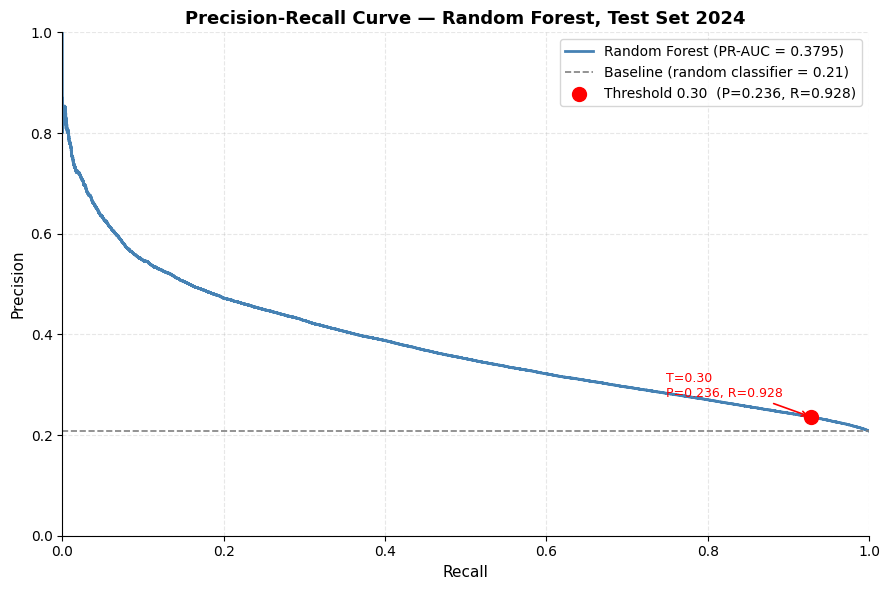


PR-AUC (sample)  : 0.3795
At threshold 0.30: Precision=0.2359, Recall=0.9282


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Sample 500K rows to keep memory manageable for curve computation
pr_sample = (
    test_predictions
    .withColumn('prob_array', vector_to_array(F.col('probability')))
    .select(F.col('ArrDel15').alias('label'), F.col('prob_array')[1].alias('score'))
    .sample(fraction=0.07, seed=42)  # ~500K rows from ~7M
    .toPandas()
)

print(f"Sample size: {len(pr_sample):,} rows")
print(f"Sample delay rate: {pr_sample['label'].mean():.4f}")

# Compute PR curve
precision_vals, recall_vals, thresholds = precision_recall_curve(
    pr_sample['label'], pr_sample['score']
)
pr_auc_score = auc(recall_vals, precision_vals)

# Find the point closest to threshold 0.30
idx_030 = (abs(thresholds - 0.30)).argmin()
p_030   = precision_vals[idx_030]
r_030   = recall_vals[idx_030]

# Baseline (random classifier = delay rate)
baseline = pr_sample['label'].mean()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(recall_vals, precision_vals, color='steelblue', linewidth=2,
        label=f'Random Forest (PR-AUC = {pr_auc_score:.4f})')
ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
           label=f'Baseline (random classifier = {baseline:.2f})')

# Mark operating point at threshold 0.30
ax.scatter(r_030, p_030, color='red', zorder=5, s=100,
           label=f'Threshold 0.30  (P={p_030:.3f}, R={r_030:.3f})')
ax.annotate(f'T=0.30\nP={p_030:.3f}, R={r_030:.3f}',
            xy=(r_030, p_030), xytext=(r_030 - 0.18, p_030 + 0.04),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

ax.set_title('Precision-Recall Curve — Random Forest, Test Set 2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10, loc='upper right')
ax.grid(alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rf_pr_curve_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPR-AUC (sample)  : {pr_auc_score:.4f}")
print(f"At threshold 0.30: Precision={p_030:.4f}, Recall={r_030:.4f}")

### Monthly Stability Analysis — Test Set (2024)

Monthly Stability Analysis — Test Set (2024) at Threshold 0.30

Month  Base Rate  Precision  Recall     F1  ROC-AUC
  Jan     0.2406     0.2622  0.9509 0.4110   0.6642
  Feb     0.1592     0.1783  0.9237 0.2990   0.6654
  Mar     0.2085     0.2370  0.9312 0.3779   0.6878
  Apr     0.1906     0.2122  0.9367 0.3460   0.6763
  May     0.2641     0.2915  0.9460 0.4456   0.6959
  Jun     0.2494     0.2692  0.9634 0.4208   0.6910
  Jul     0.2962     0.3162  0.9650 0.4763   0.7003
  Aug     0.2347     0.2503  0.9733 0.3982   0.6962
  Sep     0.1551     0.1782  0.8998 0.2975   0.6468
  Oct     0.1320     0.1602  0.8290 0.2686   0.6410
  Nov     0.1467     0.1849  0.7906 0.2997   0.6625
  Dec     0.2115     0.2385  0.8998 0.3770   0.6532
--------------------------------------------------------------
       Mean          0.2074     0.2316  0.9174  0.3681    0.6734
       Std           0.0517     0.0494  0.0560  0.0662    0.0207


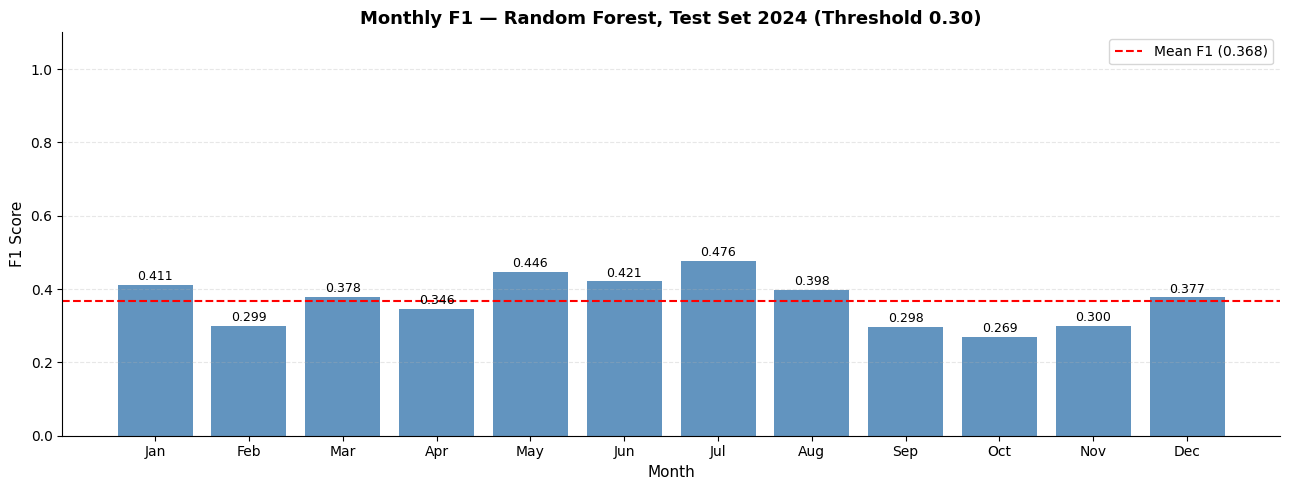

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.ml.evaluation import BinaryClassificationEvaluator

THRESHOLD = 0.30
months = list(range(1, 13))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Cache to avoid recomputing predictions 12 times for ROC-AUC loop
test_preds_thresh.cache()

# ── Confusion matrix counts for all months in one shot ─────────────────────────
monthly_cm = (
    test_preds_thresh
    .groupBy('Month')
    .agg(
        F.sum(((F.col('prediction') == 1) & (F.col('ArrDel15') == 1)).cast('int')).alias('tp'),
        F.sum(((F.col('prediction') == 1) & (F.col('ArrDel15') == 0)).cast('int')).alias('fp'),
        F.sum(((F.col('prediction') == 0) & (F.col('ArrDel15') == 1)).cast('int')).alias('fn'),
        F.sum(((F.col('prediction') == 0) & (F.col('ArrDel15') == 0)).cast('int')).alias('tn'),
        F.count('*').alias('n'),
        F.sum(F.col('ArrDel15')).alias('positives'),
    )
    .orderBy('Month')
    .toPandas()
)

monthly_cm['base_rate'] = monthly_cm['positives'] / monthly_cm['n']
monthly_cm['precision'] = monthly_cm['tp'] / (monthly_cm['tp'] + monthly_cm['fp']).replace(0, np.nan)
monthly_cm['recall']    = monthly_cm['tp'] / (monthly_cm['tp'] + monthly_cm['fn']).replace(0, np.nan)
monthly_cm['f1']        = (2 * monthly_cm['precision'] * monthly_cm['recall'] /
                           (monthly_cm['precision'] + monthly_cm['recall']).replace(0, np.nan))

# ── ROC-AUC per month ──────────────────────────────────────────────────────────
roc_evaluator = BinaryClassificationEvaluator(labelCol="ArrDel15", metricName="areaUnderROC")
roc_aucs = []
for m in months:
    month_df = test_preds_thresh.filter(F.col('Month') == m)
    roc_aucs.append(roc_evaluator.evaluate(month_df))
monthly_cm['roc_auc'] = roc_aucs
monthly_cm['Month_name'] = month_names

# ── Print summary table ────────────────────────────────────────────────────────
display_cols = ['Month_name', 'base_rate', 'precision', 'recall', 'f1', 'roc_auc']
display_df = monthly_cm[display_cols].copy()
display_df.columns = ['Month', 'Base Rate', 'Precision', 'Recall', 'F1', 'ROC-AUC']

print("Monthly Stability Analysis — Test Set (2024) at Threshold 0.30\n")
print(display_df.to_string(index=False, float_format='%.4f'))

print("-" * 62)
for stat, fn_stat in [('Mean', 'mean'), ('Std', 'std')]:
    row = getattr(display_df[['Base Rate', 'Precision', 'Recall', 'F1', 'ROC-AUC']], fn_stat)()
    print(f"{'':6} {stat:<10} {row['Base Rate']:>9.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>7.4f} {row['F1']:>7.4f} {row['ROC-AUC']:>9.4f}")

# ── Plot: F1 per month ─────────────────────────────────────────────────────────
mean_f1 = monthly_cm['f1'].mean()

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(month_names, monthly_cm['f1'], color='steelblue', alpha=0.85)
ax.axhline(mean_f1, color='red', linestyle='--', linewidth=1.5,
           label=f'Mean F1 ({mean_f1:.3f})')

for bar, val in zip(bars, monthly_cm['f1']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Monthly F1 — Random Forest, Test Set 2024 (Threshold 0.30)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rf_monthly_f1_test.png', dpi=150, bbox_inches='tight')
plt.show()